<a href="https://colab.research.google.com/github/Togunde/Mart-Sales/blob/main/MartSalesPred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Dependencies**

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [2]:
#importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from matplotlib import style
from catboost import CatBoostRegressor, Pool
style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

**Data Importing & Analysis**





In [3]:
#Train and Test datasets
train_df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')
train_df

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,row_08518,PRD-V56VKT,9.201,Regular,0.2851,Fruits and Vegetables,136.57,STORE-JOR,34,NaN,Tier_3,Corner Shop,276.50
6814,row_08519,PRD-S1AWP0,15.770,Low Fat,0.1193,FROZEN FOODS,74.03,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1265.63
6815,row_08520,PRD-NCP2VI,17.665,Low Fat,0.0182,Health and Hygiene,234.87,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,6254.55
6816,row_08521,PRD-K9LSG4,20.645,Low Fat,0.0567,snack foods,118.86,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,1658.06


In [4]:
#train shape/dimension
train_df.shape

(6818, 13)

In [5]:
test_df.shape

(1705, 12)

In [6]:
#train dataset structure summary
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [7]:
#test data structure summary
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1705 non-null   object 
 1   product_code         1705 non-null   object 
 2   product_weight_kg    1399 non-null   float64
 3   fat_content          1705 non-null   object 
 4   shelf_visibility     1705 non-null   float64
 5   product_category     1705 non-null   object 
 6   product_price        1705 non-null   float64
 7   store_code           1705 non-null   object 
 8   store_age_years      1705 non-null   int64  
 9   store_size           1214 non-null   object 
 10  store_location_tier  1705 non-null   object 
 11  store_format         1705 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 160.0+ KB


In [8]:
#no of numerical and categorical data
categorical_data=train_df.select_dtypes(include=['object'])
print("No of categorical datas:",categorical_data.shape[1])
numerical_data=train_df.select_dtypes(include=['int64','float64'])
print("No of numerical data:",numerical_data.shape[1])

No of categorical datas: 8
No of numerical data: 5


In [9]:
#statistical summary
train_df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [10]:
#checking missing values
train_df.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,1919


In [11]:
test_df.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,306
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,491


Discoveries:
- train data has 1225 product weight kg and 1919 store_size missing values with 6818 rows and 13 columns.
- test data has 306 product weight kg and 491 store_size missing values with 1705 rows and 12 columns.
- 8 categorical datas and  mumerical datas

**Product Weight**

<Axes: xlabel='product_weight_kg'>

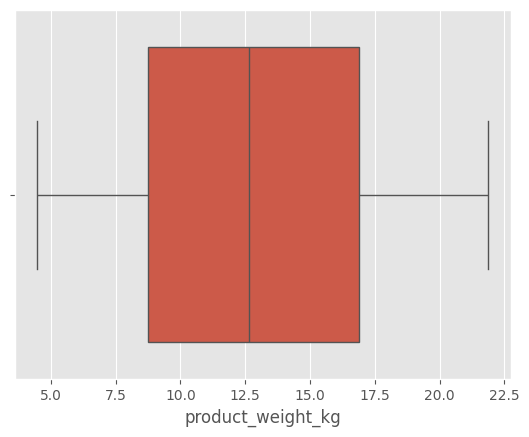

In [12]:
sns.boxplot(x=train_df['product_weight_kg'])


*Inference:No outliers*




In [13]:
#filling missing values in product weight with mean value
train_df['product_weight_kg'].fillna(train_df['product_weight_kg'].mean(), inplace=True)
test_df['product_weight_kg'].fillna(train_df['product_weight_kg'].mean(), inplace=True)

Imputed product_weight_kg  test and train data with mean of the product_weight_kg

**Shelf Visibility**

<Axes: xlabel='shelf_visibility'>

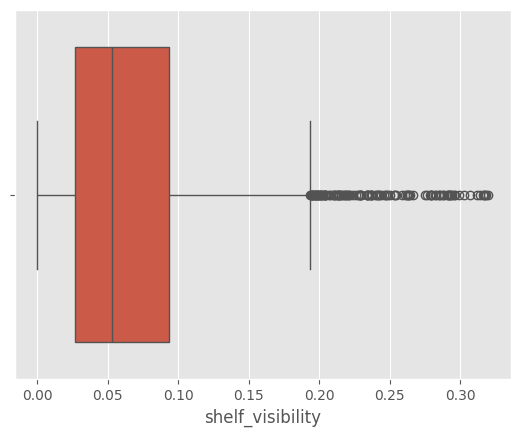

In [14]:
sns.boxplot(x=train_df['shelf_visibility'])


**Inference:**
- outliers present
- shelf_visibility=The proportion of total display area in the store allocated to this product and some have zero and they got total sales, how??

**Comparing sales of shelf visibility with zero with ones with no zero**

In [15]:
# How many zero shelf visibility values?
print("Train zeros:", (train_df['shelf_visibility'] == 0).sum())
print("Test zeros:", (test_df['shelf_visibility'] == 0).sum())
# What are the sales like for rows with zero visibility?
print(train_df[train_df['shelf_visibility'] == 0]['total_sales'].describe())
# Compare with rows where visibility is greater than zero
print(train_df[train_df['shelf_visibility'] > 0]['total_sales'].describe())

Train zeros: 422
Test zeros: 104
count     422.000000
mean     2154.615664
std      1624.750889
min        33.300000
25%       888.747500
50%      1727.960000
75%      3117.660000
max      8009.520000
Name: total_sales, dtype: float64
count     6396.000000
mean      2176.085446
std       1702.723989
min         32.700000
25%        831.735000
50%       1792.855000
75%       3092.212500
max      12996.820000
Name: total_sales, dtype: float64


Discovery:
- I firstly thought that a shelf visibility of 0 might be missing data but the sales distribution for rows with zero visibility was quite similar to the distribution for rows with visibility greater than zero.



**Store sizes**

<Axes: xlabel='store_size', ylabel='count'>

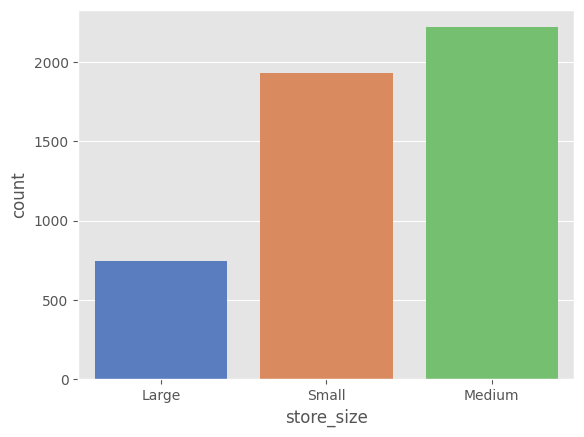

In [16]:
sns.countplot(x='store_size',data=train_df,palette="muted", legend=False)

In [17]:
train_df.groupby('store_code')['store_size'].nunique()

,store_size
store_code,
STORE-7WS,1
STORE-89Z,1
STORE-9RG,1
STORE-AGY,1
STORE-DKU,0
STORE-HL7,1
STORE-JOR,0
STORE-OYG,0
STORE-T5G,1


**Discovery:**
- while looking for what method to use to impute store_sizes, looking for the connection between store_code was needed and a unique storesize for each store_code  but couldn't use store_code because all the missing store_sizes were from particular store_codes with no store_sizes.

In [18]:
mode_of_store_size=train_df.pivot_table(values='store_size',columns='store_format',aggfunc=(lambda x:x.mode()[0]))
print(mode_of_store_size)

store_format Corner Shop Flagship Hypermarket Standard Supermarket Superstore
store_size         Small               Medium                Small     Medium


In [19]:
train_df.groupby('store_format')['store_size'].nunique()

,store_size
store_format,
Corner Shop,1
Flagship Hypermarket,1
Standard Supermarket,3
Superstore,1


In [20]:
train_df.groupby('store_format')['store_size'].nunique().mode()[0]

np.int64(1)

In [21]:
missing_values=train_df['store_size'].isnull()
print(missing_values)

0       False
1       False
2       False
3       False
4       False
        ...  
6813     True
6814     True
6815     True
6816     True
6817    False
Name: store_size, Length: 6818, dtype: bool


In [22]:
train_df.loc[missing_values,'store_size']=train_df.loc[missing_values,'store_format'].apply(lambda x:mode_of_store_size[x])

In [23]:
missing_test_values=test_df['store_size'].isnull()
print(missing_test_values)

0       False
1       False
2       False
3        True
4       False
        ...  
1700    False
1701     True
1702    False
1703    False
1704    False
Name: store_size, Length: 1705, dtype: bool


In [24]:
test_df.loc[missing_test_values,'store_size']=train_df.loc[missing_values,'store_format'].apply(lambda x:mode_of_store_size[x])

opted using the store_format to fill store_sizes.

In [25]:
train_df.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0


In [26]:
test_df.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,361


**Fat content**

<Axes: xlabel='fat_content', ylabel='count'>

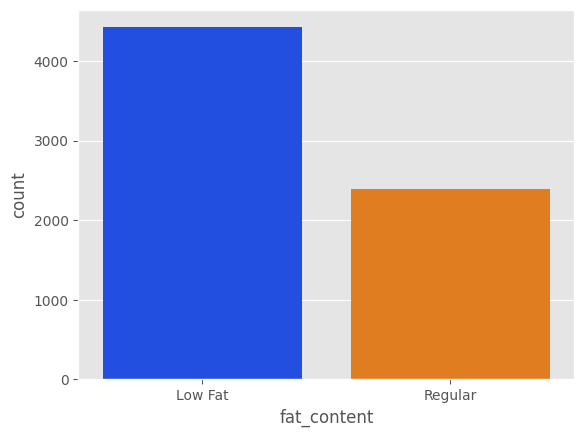

In [27]:
sns.countplot(x='fat_content',hue='fat_content',data=categorical_data,palette="bright", legend=False)

**Store code**

<Axes: xlabel='count', ylabel='store_code'>

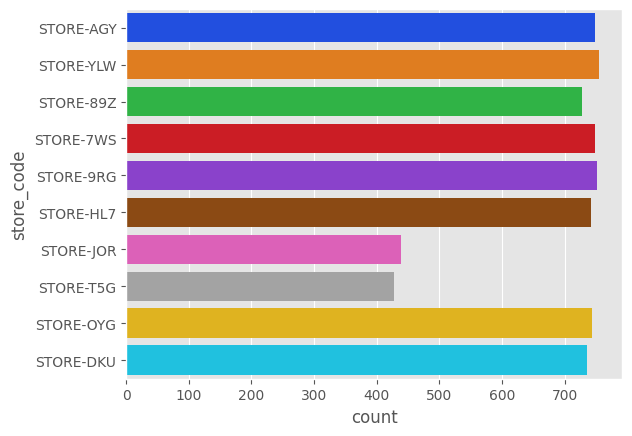

In [28]:
sns.countplot(y='store_code',hue='store_code',data=categorical_data,palette="bright", legend=False)

In [29]:
categorical_data['store_code'].value_counts()

,count
store_code,
STORE-YLW,754
STORE-9RG,752
STORE-AGY,748
STORE-7WS,748
STORE-OYG,744
STORE-HL7,742
STORE-DKU,736
STORE-89Z,728
STORE-JOR,439


<Axes: xlabel='count', ylabel='product_category'>

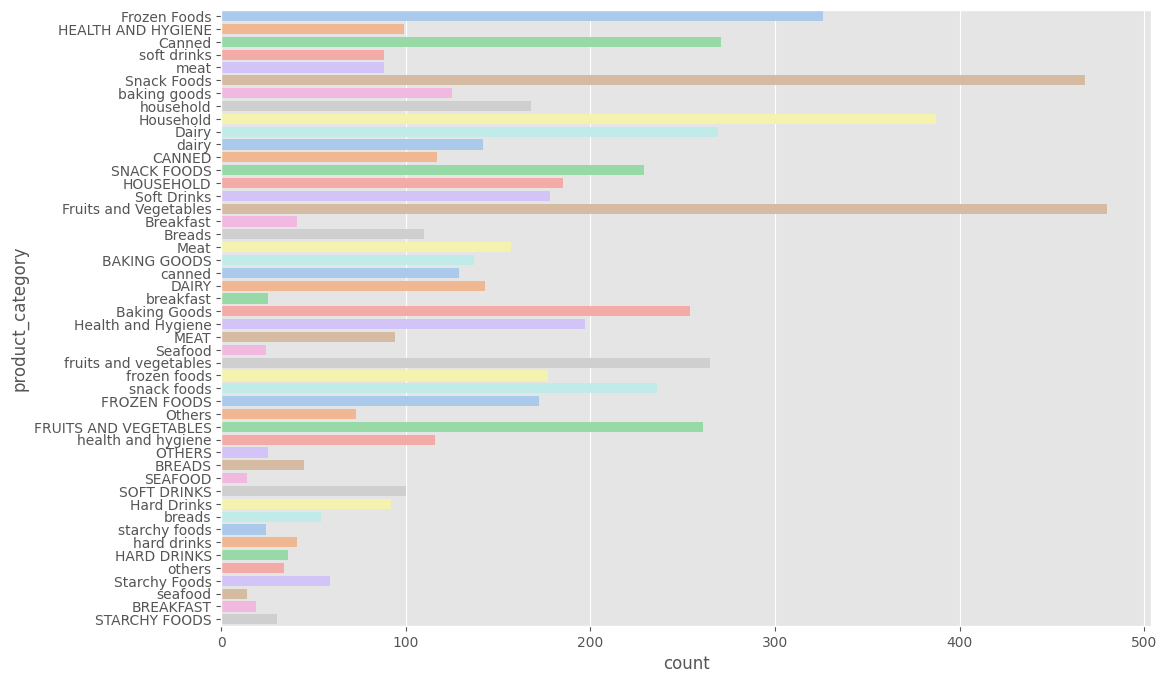

In [30]:
plt.figure(figsize=(12,8))
sns.countplot(y='product_category',data=categorical_data,palette="pastel")

**Data Preprocessing**

In [31]:
train_df['product_category'] = (train_df['product_category'].astype(str).str.lower().str.strip().str.title())
test_df['product_category'] = (test_df['product_category'].astype(str).str.lower().str.strip().str.title())

**Inference:**
- Product_category weren't in the same format had to put them in the same format

In [32]:
#the same product is sold in every store with a slightly different price, so I took the average
#(calculated from train only)
product_avg_price = train_df.groupby('product_code')['product_price'].mean()
train_df['avg_price'] = train_df['product_code'].map(product_avg_price)
test_df['avg_price'] = test_df['product_code'].map(product_avg_price)

#a few test products are not in train, so they just keep their own price
test_df['avg_price'] = test_df['avg_price'].fillna(test_df['product_price'])

#shelf_visibility of 0 is not real, so I treat it as missing and fill with the product's average visibility
train_df['shelf_visibility'] = train_df['shelf_visibility'].replace(0, np.nan)
test_df['shelf_visibility'] = test_df['shelf_visibility'].replace(0, np.nan)

product_avg_vis = train_df.groupby('product_code')['shelf_visibility'].mean()
overall_vis = train_df['shelf_visibility'].mean()

for df in [train_df, test_df]:
    df['shelf_visibility'] = df['shelf_visibility'].fillna(df['product_code'].map(product_avg_vis))
    df['shelf_visibility'] = df['shelf_visibility'].fillna(overall_vis)

**Discovery**

The same product has a little different prices across stores, so I created an average product price to capture its typical price. I also treated shelf visibility with zero as missing and replaced it with the product's average visibility.

**Store location tier and store format**

<Axes: xlabel='count', ylabel='store_location_tier'>

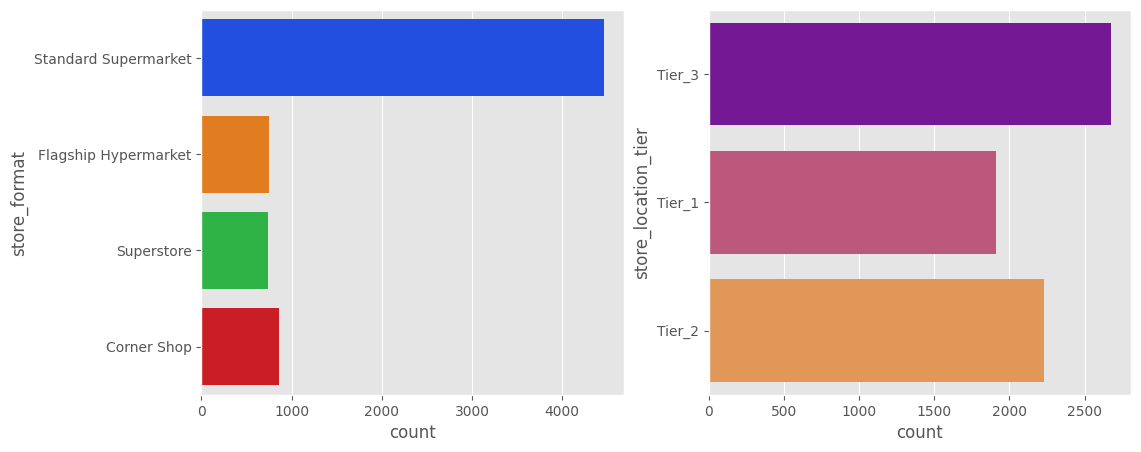

In [33]:
fig ,axes=plt.subplots(1,2, figsize=(12,5))
sns.countplot(y='store_format',palette="bright",data=categorical_data,ax=axes[0])
sns.countplot(y='store_location_tier',palette="plasma",data=categorical_data,ax=axes[1])

In [34]:
numerical_data.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


**Numerical Features**

<Axes: >

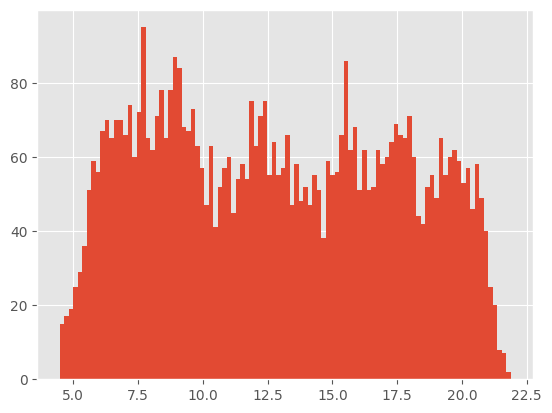

In [35]:
numerical_data['product_weight_kg'].hist(bins=100)

<Axes: >

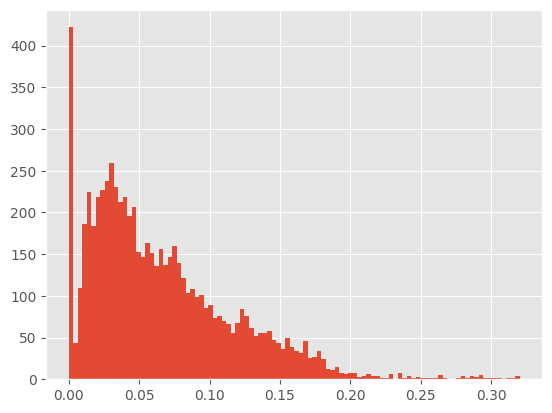

In [36]:
numerical_data['shelf_visibility'].hist(bins=100)

<Axes: >

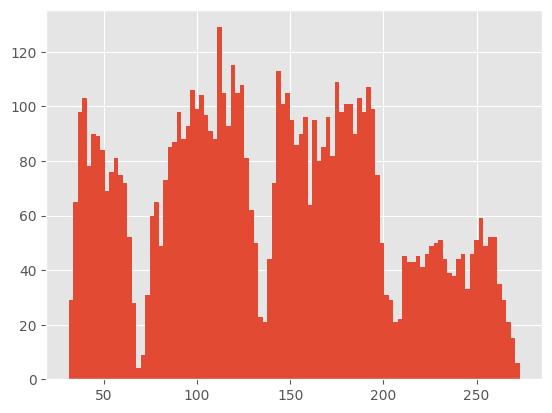

In [37]:
numerical_data['product_price'].hist(bins=100)

**Store age years**

<Axes: xlabel='store_age_years', ylabel='count'>

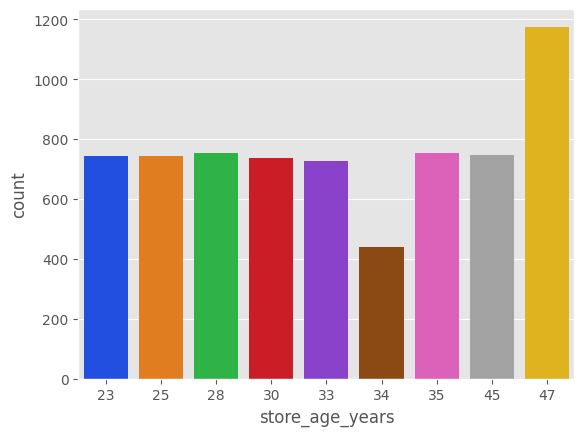

In [38]:
sns.countplot(x='store_age_years',data=numerical_data,palette="bright")

**Product category**

<Axes: xlabel='total_sales', ylabel='product_category'>

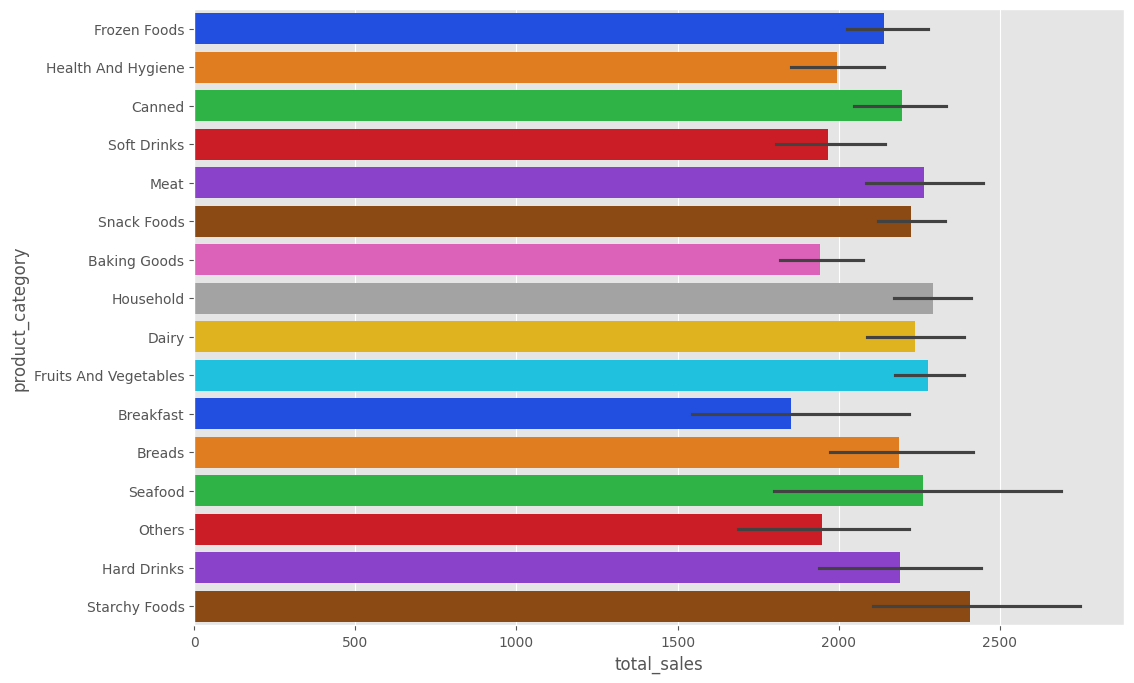

In [39]:
plt.figure(figsize=(12,8))
sns.barplot(y='product_category',x='total_sales',data=train_df, palette="bright")


**Impact of store sizes on total sales**

<Axes: xlabel='store_size', ylabel='total_sales'>

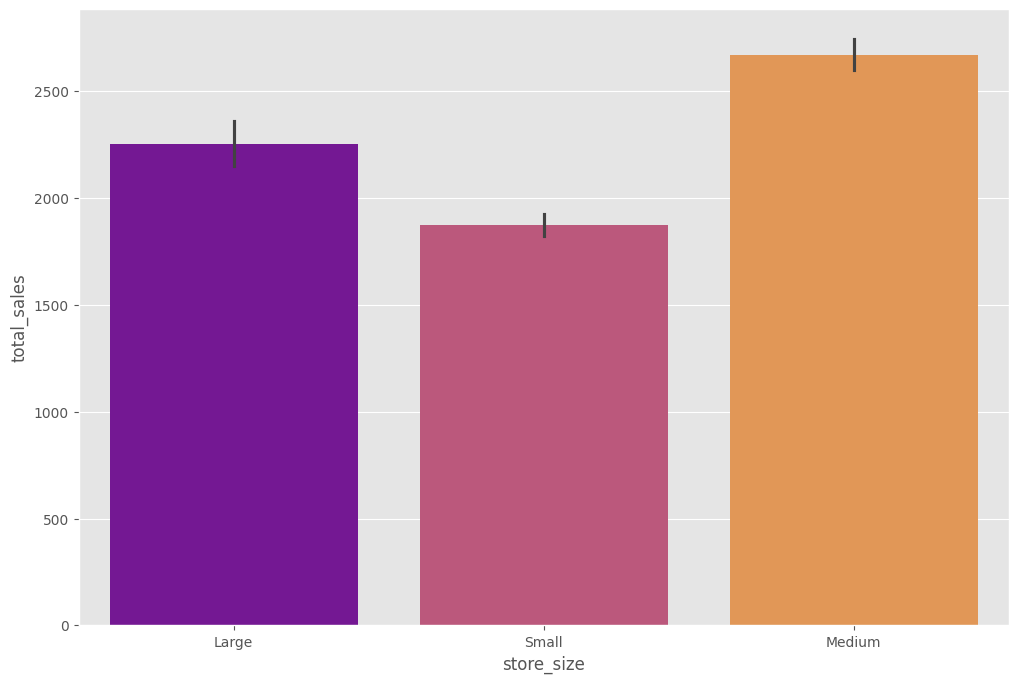

In [40]:
plt.figure(figsize=(12,8))
sns.barplot(x='store_size',y='total_sales',data=train_df, palette="plasma")


**Impact of store format and store location tier on total sales**

<Axes: xlabel='store_location_tier', ylabel='total_sales'>

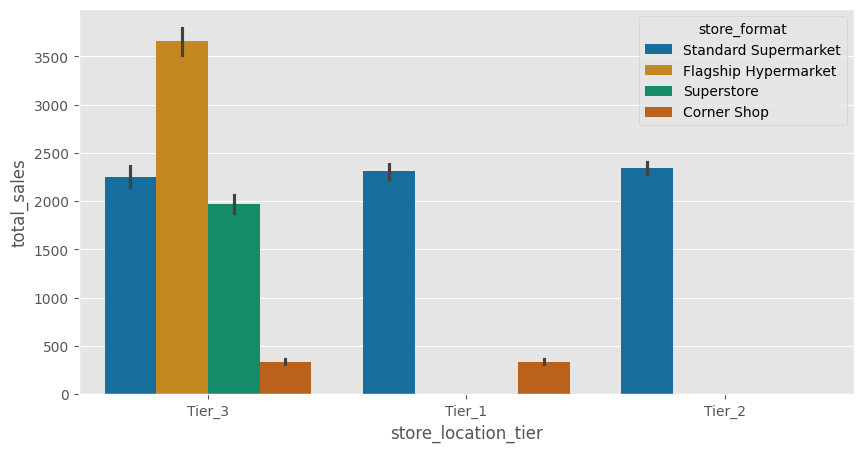

In [41]:
plt.figure(figsize=(10,5))
sns.barplot(data=train_df, x="store_location_tier",y='total_sales', hue="store_format", palette="colorblind", legend=True)


**Correlation of all numerical features on total sales**

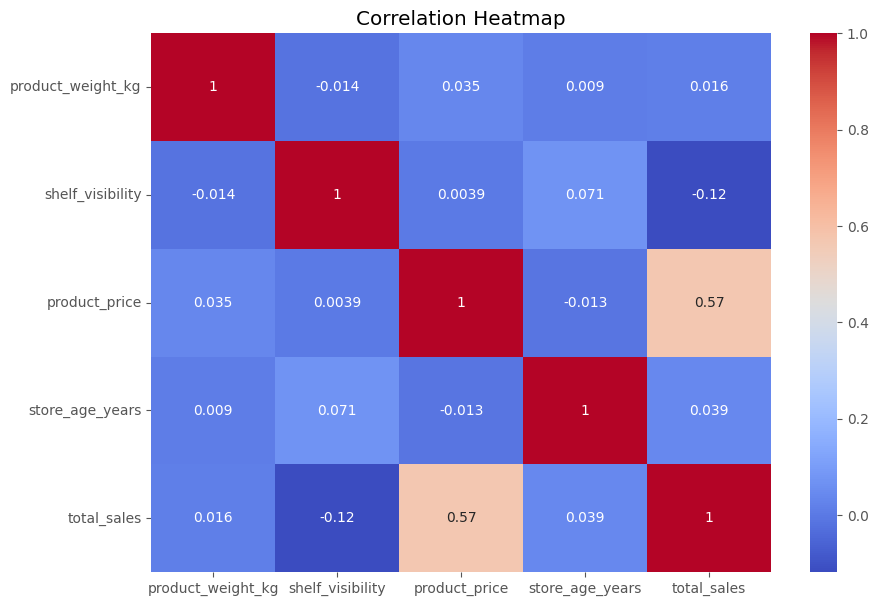

In [42]:
plt.figure(figsize=(10,7))
sns.heatmap(numerical_data.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [43]:
train_df['avg_price'] = train_df.groupby('product_code')['product_price'].transform('mean')
train_df['price_diff_pct'] = (train_df['product_price'] - train_df['avg_price']) / train_df['avg_price'] * 100

#how many sales for every 1 unit of price
train_df['sales_per_price'] = train_df['total_sales'] / train_df['avg_price']

#same thing but compared with the store's own average (1.0 = normal for that store)
train_df['relative_rate'] = train_df['sales_per_price'] / train_df.groupby('store_code')['sales_per_price'].transform('mean')

train_df['vis_clean'] = train_df['shelf_visibility'].replace(0, np.nan)

**Discovery**

- I wanted to capture how each product’s current price compares with its usual price, so I created avg_price and price_diff_pct. I also created store-relative sales features to explore how sales behave relative to price and the store’s normal level. Finally, I kept a cleaned version of shelf_visibility where zero values are treated as missing.

**Inference:**
- avg_price: typical price of the product.
- price_diff_pct : how much the current price differs from the product’s usual price.
- sales_per_price : sales relative to the product’s average price.
- relative_rate : how that sales-per-price value compares with the store’s usual level.
- vis_clean : shelf visibility with zero values treated as missing.

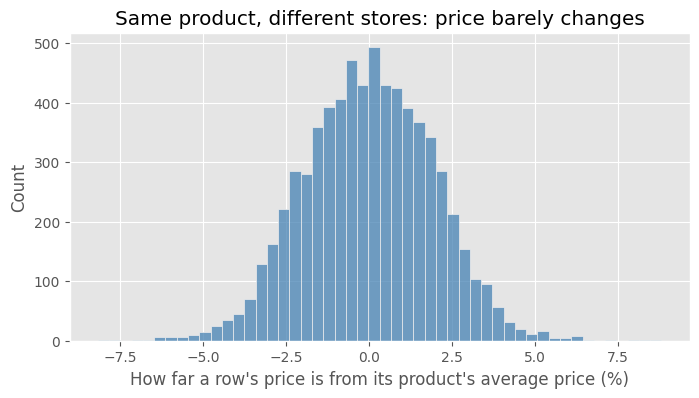

In [44]:
plt.figure(figsize=(8,4))
sns.histplot(train_df['price_diff_pct'], bins=50, color='steelblue')
plt.xlabel("How far a row's price is from its product's average price (%)")
plt.title('Same product, different stores: price barely changes')
plt.show()

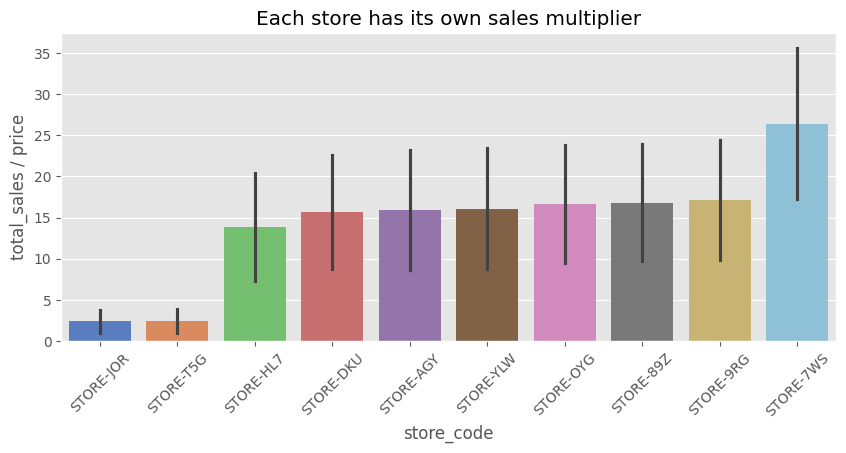

In [45]:
plt.figure(figsize=(10,4))
order = train_df.groupby('store_code')['sales_per_price'].mean().sort_values().index
sns.barplot(data=train_df, x='store_code', y='sales_per_price', order=order, errorbar='sd', palette='muted')
plt.xticks(rotation=45)
plt.ylabel('total_sales / price')
plt.title('Each store has its own sales multiplier')
plt.show()

Inference from the analysis:
- categorical data =8
- numerical data=5
- For store_size the data has mostly medium
- Also majority of the products has low fat content compared to regular fat content
- Majority of the products were Snack Foods  and Fruits and Vegetables
- Based on store_format majority of the stores are Standard supermarket
- Products contributing mostly to the total sales are seafoods and starchy foods
- Total sales are higher for sales whose store_size is medium
- Tier 3 has higher sales compared to other stores
- The product price has the highest correlation with total sales
-

Splitting Features and Targets

In [46]:
id = test_df.id
y = train_df["total_sales"]

features = ['avg_price', 'shelf_visibility', 'store_code', 'product_category']
X = train_df[features]
X_test = test_df[features]

In [47]:
print(X.shape)
print(y.shape)

(6818, 4)
(6818,)


In [48]:
#Split into validation and training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3,random_state=1)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((4772, 4), (2046, 4), (4772,), (2046,))

Machine Learning Model Training

In [50]:
model = CatBoostRegressor(n_estimators=250, learning_rate=0.05, depth=3,l2_leaf_reg=10, random_state=42, verbose=0)
pool_train = Pool(X_train, y_train, cat_features =['store_code', 'product_category'])
pool_test = Pool(X_val, cat_features =['store_code', 'product_category'])
model.fit(pool_train)
model_pred = model.predict(pool_test)

**Evaluation**

In [51]:
model_rmse=metrics.root_mean_squared_error(y_val,model_pred)
model_r2=metrics.r2_score(y_val,model_pred)
print("RMSE:",model_rmse)
print("R2 Score:",model_r2)

RMSE: 1077.533349394431
R2 Score: 0.5917176545643403


**Final Model**

In [52]:
categorical_cols = ['store_code', 'product_category']

#training  the model 5 times with different seeds and average the predictions
cb_preds = []
for seed in range(5):
    cb = CatBoostRegressor(n_estimators=250, learning_rate=0.05, depth=3, l2_leaf_reg=10, random_state=seed, verbose=0)
    cb.fit(X, y, cat_features=categorical_cols)
    cb_preds.append(cb.predict(X_test))

predictions = np.mean(cb_preds, axis=0)

**Thought Process:**

After making multiple predictions while splitting my train and test data for an evaluation on hoe the metrics works , I really didnt do well on the leaderboard but then I tried using all my train data just to train and the model worked better on the test data given.Also many other models were tried like linear regression, random forest, and xgboost but catboost was chosen because it handles categorical data better and had a better rmse valuation score.

**Feature Importance**

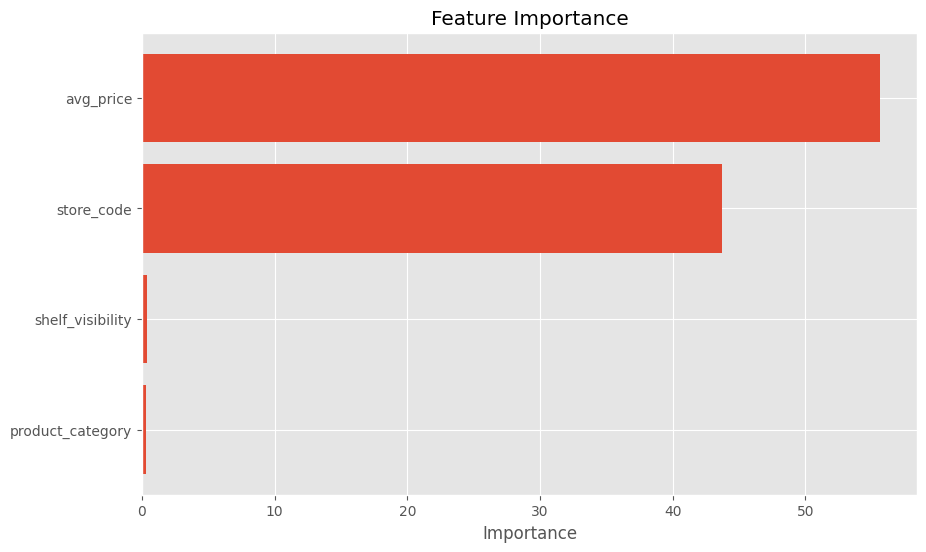

In [53]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cb.get_feature_importance()
})

importance = importance.sort_values('importance')

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

In [54]:
predictions=cb.predict(X_test)
predictions

array([3044.39858742, 4289.69420212, 2991.36208289, ..., 2930.88055713,
       4459.90027441, 1658.92458724])

In [55]:
#Load Sample submission file
sample=pd.read_csv("/content/sample_submission.csv")
sample

,id,total_sales
0,row_00009,2174.76
1,row_00015,2174.76
2,row_00019,2174.76
3,row_00020,2174.76
4,row_00023,2174.76
...,...,...
1700,row_08483,2174.76
1701,row_08489,2174.76
1702,row_08491,2174.76
1703,row_08504,2174.76


In [56]:
output=pd.DataFrame({'id':id,'total_sales':predictions})
output.to_csv('submission.csv',index=False)
output

,id,total_sales
0,row_00009,3044.398587
1,row_00015,4289.694202
2,row_00019,2991.362083
3,row_00020,3156.617720
4,row_00023,2413.083101
...,...,...
1700,row_08483,2833.360153
1701,row_08489,238.475630
1702,row_08491,2930.880557
1703,row_08504,4459.900274


In [57]:
print(output.shape)
print(output.isnull().sum())

(1705, 2)
id             0
total_sales    0
dtype: int64


In [58]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Final Thoughts:**

Adding more features doesnt necessarily mean getting a better model,I first tried using all the features but the smaller feature gave me a better model but this features were gotten from the features not used in the model.
For the final submission, I used the feature set and CatBoost configuration that gave me the most consistent results in my experiments.